<a href="https://colab.research.google.com/github/Pam-Pam29/Summative-Assignment---Mission-Based-Reinforcement-Learning/blob/main/notebooks/fakunle_victoria_rl_dqn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sista Health RL — DQN (Deep Q-Network)
**Victoria Fakunle | ALU 2026**

This notebook trains a DQN agent on the Sista Health environment and runs 10 hyperparameter experiments.

**Environment:** A Nigerian woman sends a maternal/sexual health query. The agent decides the best response strategy.

**Action Space:** Text Response | Voice Note | Emergency Referral | Clarify

**Observation Space:** language, domain, topic, urgency, literacy, session_step

## Step 1 — Install Libraries

In [1]:
!pip install gymnasium stable-baselines3 numpy pandas matplotlib -q
print(' Libraries installed!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 9.5 MB/s eta 0:00:00
 Libraries installed!


## Step 2 — Define Sista Health Environment

In [3]:
import gymnasium as gym
import numpy as np
from gymnasium import spaces

class SistaHealthEnv(gym.Env):
  """
  Sista Health Custom RL Environment
  ====================================
  Simulates a Nigerian woman sending an SRH/maternal health query.
  The agent learns the optimal response strategy.

  Observation Space (6 features):
  language: 0=English, 1=Yoruba, 2=Pidgin
  domain: 0=Sexual Health, 1=Maternal Health
  topic: 0-8 (9 health topics)
  urgency: 0=Normal, 1=Emergency
  literacy: 0=Low, 1=Medium, 2=High
  session_step: 0-9

  Action Space (4 discrete actions):
  0 = Text Response
  1 = Voice Note
  2 = Emergency Referral
  3 = Ask Clarifying Question
  """

  TOPICS = ['FGM Complications','VVF Causes','Cultural Barriers',
  'Early Marriage','TBA Dangers','Contraception',
  'STIs & HIV','Antenatal Care','Postpartum Care']
  LANGUAGES = ['English','Yoruba','Pidgin']
  DOMAINS = ['Sexual Health','Maternal Health']
  ACTIONS = ['Text Response','Voice Note','Emergency Referral','Clarify']

  def __init__(self):
    super().__init__()
    self.observation_space = spaces.Box(
    low=np.array([0,0,0,0,0,0], dtype=np.float32),
    high=np.array([2,1,8,1,2,9], dtype=np.float32),
    dtype=np.float32
    )
    self.action_space = spaces.Discrete(4)
    self.state = None
    self.step_count = 0
    self.episode_reward = 0
    self.last_action = None
    self.last_reward = 0
    self.last_feedback = ''

  def _get_obs(self):
    return self.state.astype(np.float32)

  def _get_info(self):
    return {
    'language': self.LANGUAGES[int(self.state[0])],
    'domain': self.DOMAINS[int(self.state[1])],
    'topic': self.TOPICS[int(self.state[2])],
    'urgency': 'Emergency' if self.state[3]==1 else 'Normal',
    'literacy': ['Low','Medium','High'][int(self.state[4])],
    'episode_reward': self.episode_reward
    }

  def reset(self, seed=None, options=None):
    super().reset(seed=seed)
    self.state = np.array([
    self.np_random.integers(0,3),
    self.np_random.integers(0,2),
    self.np_random.integers(0,9),
    1 if self.np_random.random() < 0.2 else 0,
    self.np_random.integers(0,3),
    0
    ], dtype=np.float32)
    self.step_count=0; self.episode_reward=0
    self.last_action=None; self.last_reward=0
    self.last_feedback='New session'
    return self._get_obs(), self._get_info()

  def step(self, action):
    urgency=int(self.state[3]); literacy=int(self.state[4]); language=int(self.state[0])
    reward=0; terminated=False; feedback=''

    if action==2: # Emergency
      if urgency==1: reward+=10; feedback='Emergency escalated! +10'; terminated=True
      else: reward-=3; feedback='Unnecessary emergency. -3'
    elif action==0: # Text
      if urgency==1: reward-=10; feedback='Emergency missed! -10'
      elif literacy==2: reward+=5; feedback='Text great for high literacy. +5'
      elif literacy==1: reward+=2; feedback='Text ok for medium literacy. +2'
      else: reward-=2; feedback='Text poor for low literacy. -2'
    elif action==1: # Voice
      if urgency==1: reward-=10; feedback='Emergency missed! -10'
      elif literacy==0: reward+=10; feedback='Voice perfect for low literacy! +10'
      elif literacy==1: reward+=5; feedback='Voice good for medium. +5'
      else: reward+=1; feedback='Voice ok for high literacy. +1'
    if language==2: reward+=1; feedback+=' (Pidgin +1)'
    elif action==3: # Clarify
      if urgency==1: reward-=2; feedback='No clarify in emergency! -2'
      else: reward+=1; feedback='Clarification. +1'

    self.state[5]=min(self.state[5]+1,9)
    self.step_count+=1
    self.last_action=action; self.last_reward=reward
    self.last_feedback=feedback; self.episode_reward+=reward
    if self.step_count>=10: terminated=True
    return self._get_obs(), reward, terminated, False, self._get_info()

  def render(self): pass
  def close(self): pass

# Quick test
env = SistaHealthEnv()
obs, info = env.reset(seed=42)
print(' Environment created!')
print(f' User: {info["language"]} | {info["domain"]} | Urgency: {info["urgency"]} | Literacy: {info["literacy"]}')
print(f' Observation shape: {obs.shape}')
print(f' Action space: {env.action_space.n} actions')

 Environment created!
 User: English | Maternal Health | Urgency: Normal | Literacy: Medium
 Observation shape: (6,)
 Action space: 4 actions


## Step 3 — Random Agent Demo (No Model)
This demonstrates the environment components without any training.

In [4]:
import os
os.makedirs('models/dqn', exist_ok=True)
os.makedirs('results', exist_ok=True)

env = SistaHealthEnv()
obs, info = env.reset(seed=42)

print('='*55)
print(' RANDOM AGENT DEMO — No Training Involved')
print('='*55)
print(f' User: {info["language"]} | {info["domain"]} | Urgency: {info["urgency"]}')
print('-'*55)

total_r, done, step = 0, False, 0
while not done:
 action = env.action_space.sample() # RANDOM — no model used
 obs, reward, term, trunc, info = env.step(action)
 print(f' Step {step+1:2d} | Action: {env.ACTIONS[action]:20s} | Reward: {reward:+.0f}')
 print(f' → {env.last_feedback}')
 total_r += reward; done = term or trunc; step += 1

print('-'*55)
print(f' Total Episode Reward (random): {total_r}')
env.close()

 RANDOM AGENT DEMO — No Training Involved
 User: English | Maternal Health | Urgency: Normal
-------------------------------------------------------
 Step  1 | Action: Clarify              | Reward: +1
 → Clarification. +1
 Step  2 | Action: Voice Note           | Reward: +5
 → Voice good for medium. +5
 Step  3 | Action: Emergency Referral   | Reward: -3
 → Unnecessary emergency. -3
 Step  4 | Action: Text Response        | Reward: +2
 → Text ok for medium literacy. +2
 Step  5 | Action: Voice Note           | Reward: +5
 → Voice good for medium. +5
 Step  6 | Action: Emergency Referral   | Reward: -3
 → Unnecessary emergency. -3
 Step  7 | Action: Emergency Referral   | Reward: -3
 → Unnecessary emergency. -3
 Step  8 | Action: Emergency Referral   | Reward: -3
 → Unnecessary emergency. -3
 Step  9 | Action: Emergency Referral   | Reward: -3
 → Unnecessary emergency. -3
 Step 10 | Action: Text Response        | Reward: +2
 → Text ok for medium literacy. +2
---------------------------

## Step 4 — Define Callback & Evaluate Function

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
from stable_baselines3 import DQN
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.monitor import Monitor

class RewardCallback(BaseCallback):
  """Logs episode rewards and steps during training."""
  def __init__(self):
    super().__init__()
    self.rewards_per_episode = []
    self.steps_per_episode = []
    self._current_rewards = []
    self._current_steps = 0

  def _on_step(self):
    self._current_rewards.append(self.locals['rewards'][0])
    self._current_steps += 1
    if self.locals['dones'][0]:
      self.rewards_per_episode.append(sum(self._current_rewards))
      self.steps_per_episode.append(self._current_steps)
      self._current_rewards = []
      self._current_steps = 0
    return True

def evaluate_model(model, n_episodes=20):
  """Evaluate trained model and return mean/std reward."""
  env = SistaHealthEnv()
  rewards = []
  for _ in range(n_episodes):
    obs, _ = env.reset()
    ep_r, done = 0, False
    while not done:
      action, _ = model.predict(obs, deterministic=True)
      obs, r, term, trunc, _ = env.step(int(action))
      ep_r += r; done = term or trunc
    rewards.append(ep_r)
  env.close()
  return np.mean(rewards), np.std(rewards)

print(' Callback and evaluate function ready!')

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


 Callback and evaluate function ready!


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Step 5 — DQN Hyperparameter Experiments (10 Runs)
Each run changes one hyperparameter.

In [9]:
TIMESTEPS = 50000

EXPERIMENTS = [
 {'learning_rate':1e-3, 'gamma':0.99, 'batch_size':32, 'buffer_size':10000, 'exploration_fraction':0.3},
 {'learning_rate':5e-4, 'gamma':0.99, 'batch_size':32, 'buffer_size':10000, 'exploration_fraction':0.3},
 {'learning_rate':1e-4, 'gamma':0.99, 'batch_size':32, 'buffer_size':10000, 'exploration_fraction':0.3},
 {'learning_rate':1e-3, 'gamma':0.95, 'batch_size':32, 'buffer_size':10000, 'exploration_fraction':0.3},
 {'learning_rate':1e-3, 'gamma':0.90, 'batch_size':32, 'buffer_size':10000, 'exploration_fraction':0.3},
 {'learning_rate':1e-3, 'gamma':0.99, 'batch_size':64, 'buffer_size':10000, 'exploration_fraction':0.3},
 {'learning_rate':1e-3, 'gamma':0.99, 'batch_size':128, 'buffer_size':10000, 'exploration_fraction':0.3},
 {'learning_rate':1e-3, 'gamma':0.99, 'batch_size':32, 'buffer_size':50000, 'exploration_fraction':0.3},
 {'learning_rate':1e-3, 'gamma':0.99, 'batch_size':32, 'buffer_size':10000, 'exploration_fraction':0.1},
 {'learning_rate':1e-3, 'gamma':0.99, 'batch_size':32, 'buffer_size':10000, 'exploration_fraction':0.5},
]

results, callbacks = [], []

for i, p in enumerate(EXPERIMENTS):
 print(f'[Run {i+1}/10] lr={p["learning_rate"]} | gamma={p["gamma"]} | '
 f'batch={p["batch_size"]} | buffer={p["buffer_size"]} | explore={p["exploration_fraction"]}')

 env = Monitor(SistaHealthEnv())
 cb = RewardCallback()

 model = DQN('MlpPolicy', env,
 learning_rate=p['learning_rate'],
 gamma=p['gamma'],
 batch_size=p['batch_size'],
 buffer_size=p['buffer_size'],
 exploration_fraction=p['exploration_fraction'],
 exploration_final_eps=0.05,
 verbose=0)

 model.learn(total_timesteps=TIMESTEPS, callback=cb)
 mean_r, std_r = evaluate_model(model)
 print(f' → Mean Reward: {mean_r:.2f} ± {std_r:.2f}')

 if not results or mean_r > max(r['mean_r'] for r in results):
  model.save('models/dqn/best_dqn_model')
  print(' → New best! Model saved.')

 results.append({
 'Run': i+1,
 'Learning Rate': p['learning_rate'],
 'Gamma': p['gamma'],
 'Batch Size': p['batch_size'],
 'Buffer Size': p['buffer_size'],
 'Exploration Fraction': p['exploration_fraction'],
 'mean_r': mean_r,
 'Mean Reward': round(mean_r, 2),
 'Std Reward': round(std_r, 2)
 })
 callbacks.append(cb)
 env.close()

print('\n All 10 DQN experiments complete!')

[Run 1/10] lr=0.001 | gamma=0.99 | batch=32 | buffer=10000 | explore=0.3
 → Mean Reward: 66.95 ± 38.15
 → New best! Model saved.
[Run 2/10] lr=0.0005 | gamma=0.99 | batch=32 | buffer=10000 | explore=0.3


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


 → Mean Reward: 59.05 ± 30.36
[Run 3/10] lr=0.0001 | gamma=0.99 | batch=32 | buffer=10000 | explore=0.3
 → Mean Reward: 54.50 ± 24.99
[Run 4/10] lr=0.001 | gamma=0.95 | batch=32 | buffer=10000 | explore=0.3
 → Mean Reward: 59.25 ± 26.17
[Run 5/10] lr=0.001 | gamma=0.9 | batch=32 | buffer=10000 | explore=0.3
 → Mean Reward: 49.55 ± 32.26
[Run 6/10] lr=0.001 | gamma=0.99 | batch=64 | buffer=10000 | explore=0.3
 → Mean Reward: 58.10 ± 31.06
[Run 7/10] lr=0.001 | gamma=0.99 | batch=128 | buffer=10000 | explore=0.3
 → Mean Reward: 63.45 ± 32.82
[Run 8/10] lr=0.001 | gamma=0.99 | batch=32 | buffer=50000 | explore=0.3
 → Mean Reward: 55.40 ± 35.24
[Run 9/10] lr=0.001 | gamma=0.99 | batch=32 | buffer=10000 | explore=0.1
 → Mean Reward: 58.10 ± 29.27
[Run 10/10] lr=0.001 | gamma=0.99 | batch=32 | buffer=10000 | explore=0.5
 → Mean Reward: 58.90 ± 32.97

 All 10 DQN experiments complete!


## Step 6 — Results Table

In [10]:
df = pd.DataFrame(results).drop(columns=['mean_r'])
df.to_csv('results/dqn_results.csv', index=False)

print('DQN HYPERPARAMETER EXPERIMENT RESULTS')
print('='*75)
print(df.to_string(index=False))
print('='*75)

best = df.loc[df['Mean Reward'].idxmax()]
print(f'\n Best Run: #{int(best["Run"])} | Mean Reward: {best["Mean Reward"]}')
print(f' lr={best["Learning Rate"]} | gamma={best["Gamma"]} | batch={best["Batch Size"]}')

DQN HYPERPARAMETER EXPERIMENT RESULTS
 Run  Learning Rate  Gamma  Batch Size  Buffer Size  Exploration Fraction  Mean Reward  Std Reward
   1         0.0010   0.99          32        10000                   0.3        66.95       38.15
   2         0.0005   0.99          32        10000                   0.3        59.05       30.36
   3         0.0001   0.99          32        10000                   0.3        54.50       24.99
   4         0.0010   0.95          32        10000                   0.3        59.25       26.17
   5         0.0010   0.90          32        10000                   0.3        49.55       32.26
   6         0.0010   0.99          64        10000                   0.3        58.10       31.06
   7         0.0010   0.99         128        10000                   0.3        63.45       32.82
   8         0.0010   0.99          32        50000                   0.3        55.40       35.24
   9         0.0010   0.99          32        10000                   0

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Step 7 — Plots
Cumulative rewards, training curve, learning rate effect, gamma effect.

/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:85: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:89: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2010: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  p.space          = oneOf(self._space_widths)("space")
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2020: PyparsingDeprecationWarning: 'leaveWhitespace' deprecated - use 'leave_whitespace'
  )("sym").leaveWhitespace()
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:1984: PyparsingDeprecationWarning: 'setName' deprecated - use 'set_name'
  val.setName(key)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:1987: PyparsingDeprecationWarning: 'setParseA

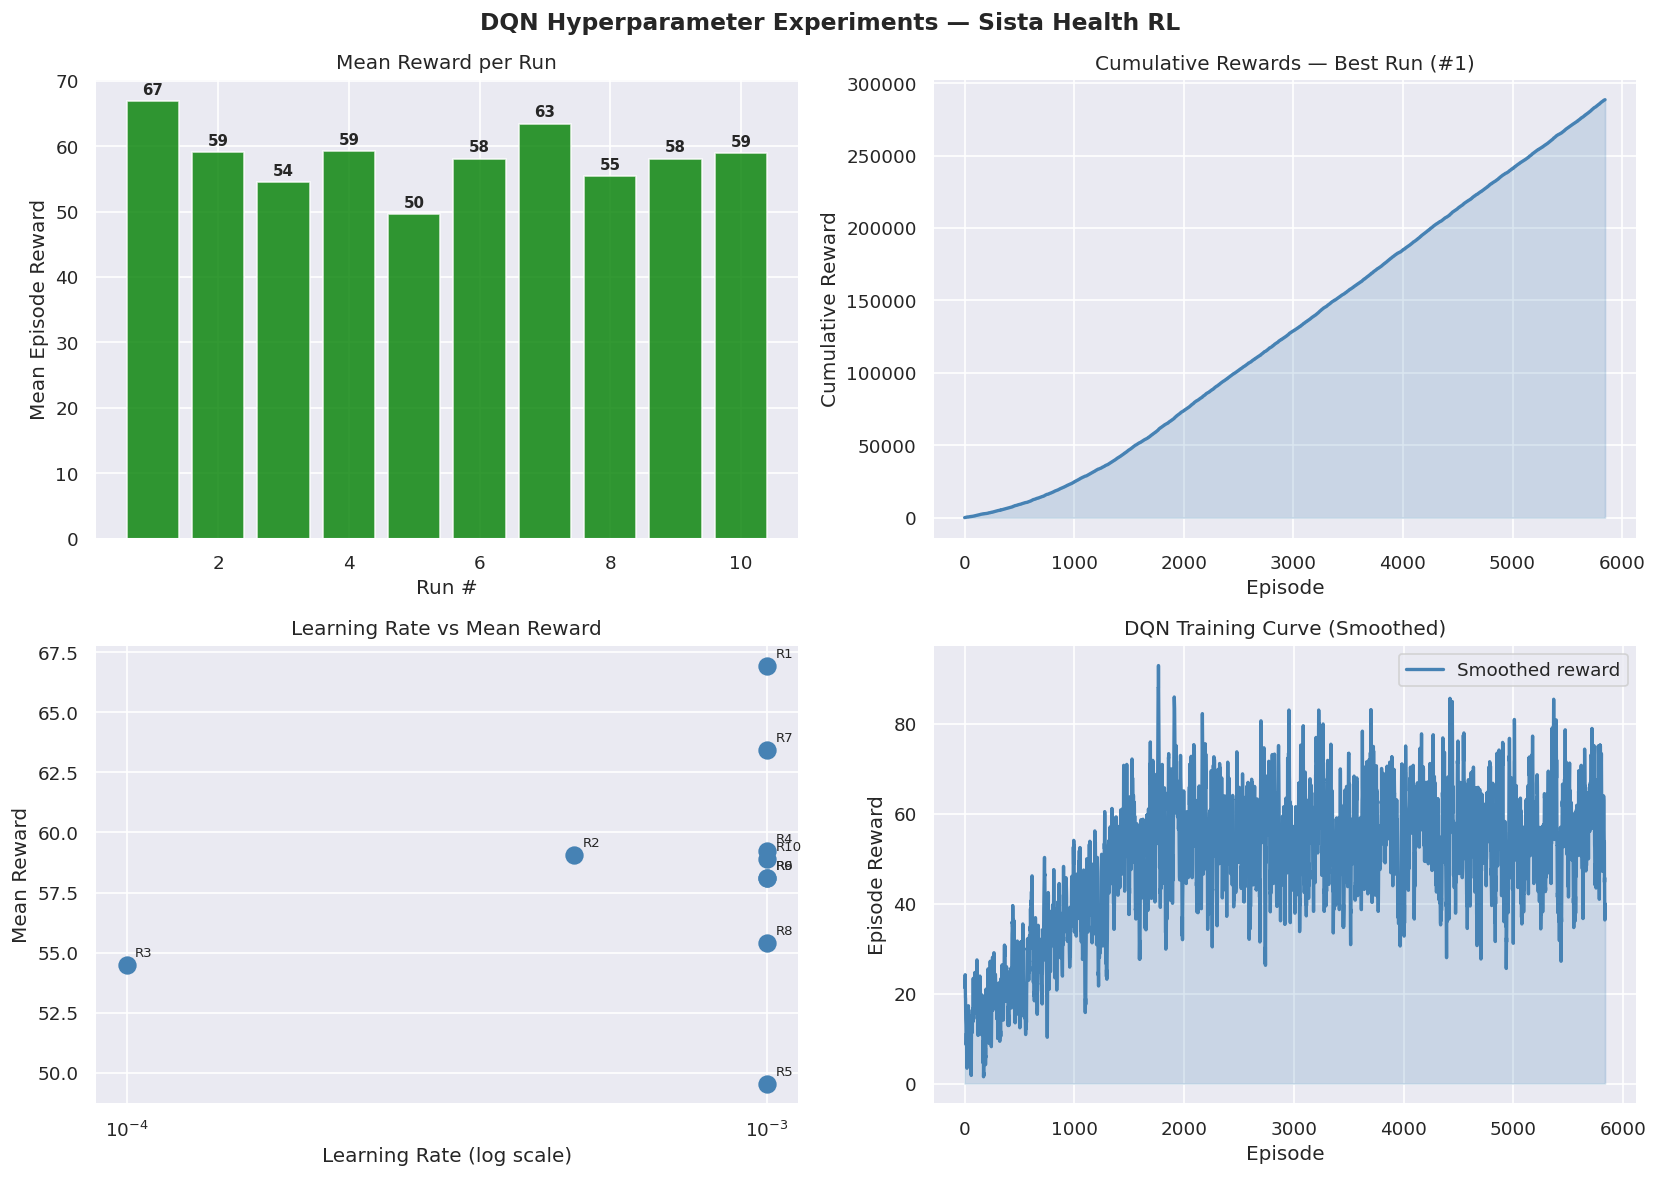

 Saved: results/dqn_plots.png


In [11]:
import seaborn as sns
sns.set(style='darkgrid')

best_idx = df['Mean Reward'].idxmax()
best_cb = callbacks[best_idx]
means = df['Mean Reward'].tolist()
runs = df['Run'].tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('DQN Hyperparameter Experiments — Sista Health RL', fontsize=14, fontweight='bold')

# Plot 1: Mean reward per run
colors = ['green' if m > 0 else 'red' for m in means]
axes[0,0].bar(runs, means, color=colors, alpha=0.8)
axes[0,0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0,0].set_title('Mean Reward per Run')
axes[0,0].set_xlabel('Run #'); axes[0,0].set_ylabel('Mean Episode Reward')
for i, v in enumerate(means):
 axes[0,0].text(i+1, v+1, f'{v:.0f}', ha='center', fontsize=9, fontweight='bold')

# Plot 2: Best training curve (cumulative rewards)
rewards = best_cb.rewards_per_episode
cumulative = np.cumsum(rewards)
axes[0,1].plot(cumulative, color='steelblue', linewidth=2)
axes[0,1].fill_between(range(len(cumulative)), cumulative, alpha=0.2, color='steelblue')
axes[0,1].set_title(f'Cumulative Rewards — Best Run (#{best_idx+1})')
axes[0,1].set_xlabel('Episode'); axes[0,1].set_ylabel('Cumulative Reward')

# Plot 3: Learning rate effect
lrs = df['Learning Rate'].tolist()
axes[1,0].scatter(lrs, means, color='steelblue', s=100, zorder=5)
axes[1,0].set_xscale('log')
axes[1,0].set_title('Learning Rate vs Mean Reward')
axes[1,0].set_xlabel('Learning Rate (log scale)'); axes[1,0].set_ylabel('Mean Reward')
for i, (x, y) in enumerate(zip(lrs, means)):
 axes[1,0].annotate(f'R{i+1}', (x, y), textcoords='offset points', xytext=(5,5), fontsize=8)

# Plot 4: Smoothed training curve
if len(rewards) > 10:
 smoothed = np.convolve(rewards, np.ones(10)/10, mode='valid')
 axes[1,1].plot(smoothed, color='steelblue', linewidth=2, label='Smoothed reward')
 axes[1,1].fill_between(range(len(smoothed)), smoothed, alpha=0.2, color='steelblue')
axes[1,1].set_title('DQN Training Curve (Smoothed)')
axes[1,1].set_xlabel('Episode'); axes[1,1].set_ylabel('Episode Reward')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('results/dqn_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: results/dqn_plots.png')

## Step 8 — Run Best DQN Agent

In [13]:
best_model = DQN.load('models/dqn/best_dqn_model')
env = SistaHealthEnv()
all_rewards = []

for ep in range(5):
    obs, info = env.reset()
    ep_r, done, step = 0, False, 0
    print(f'\n{"="*55}')
    print(f' EPISODE {ep+1} | {info["language"]} | {info["domain"]} | Urgency: {info["urgency"]} | Literacy: {info["literacy"]}')
    print(f'{"─"*55}')
    while not done:
        action, _ = best_model.predict(obs, deterministic=True)
        obs, r, term, trunc, info = env.step(int(action))
        sign = '' if r > 0 else ('' if r == 0 else '')
        print(f' Step {step+1:2d} | {env.ACTIONS[int(action)]:20s} | {r:+.0f} {sign}')
        ep_r += r
        step += 1
        done = term or trunc
    print(f' Episode Reward: {ep_r:.1f}')
    all_rewards.append(ep_r)

print(f'\n{"="*55}')
print(f' SUMMARY — DQN Agent')
print(f' Mean Reward: {np.mean(all_rewards):.2f}')
print(f' Best Episode: {max(all_rewards):.1f}')
env.close()


 EPISODE 1 | Pidgin | Sexual Health | Urgency: Normal | Literacy: Medium
───────────────────────────────────────────────────────
 Step  1 | Voice Note           | +6 
 Step  2 | Voice Note           | +6 
 Step  3 | Voice Note           | +6 
 Step  4 | Voice Note           | +6 
 Step  5 | Voice Note           | +6 
 Step  6 | Voice Note           | +6 
 Step  7 | Voice Note           | +6 
 Step  8 | Voice Note           | +6 
 Step  9 | Voice Note           | +6 
 Step 10 | Voice Note           | +6 
 Episode Reward: 60.0

 EPISODE 2 | English | Sexual Health | Urgency: Normal | Literacy: Low
───────────────────────────────────────────────────────
 Step  1 | Voice Note           | +10 
 Step  2 | Voice Note           | +10 
 Step  3 | Voice Note           | +10 
 Step  4 | Voice Note           | +10 
 Step  5 | Voice Note           | +10 
 Step  6 | Voice Note           | +10 
 Step  7 | Voice Note           | +10 
 Step  8 | Voice Note           | +10 
 Step  9 | Voice Note       

## Step 9 — Download Results

In [14]:
import shutil
from google.colab import files
shutil.make_archive('dqn_results', 'zip', 'results')
files.download('dqn_results.zip')
print(' Downloaded!')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 Downloaded!


In [15]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [16]:
from google.colab import drive
drive.mount('/content/drive')

import shutil, os
os.makedirs('/content/drive/MyDrive/sista_health_rl/models/dqn', exist_ok=True)
os.makedirs('/content/drive/MyDrive/sista_health_rl/results', exist_ok=True)

# Copy model to Drive
shutil.copy('models/dqn/best_dqn_model.zip',
            '/content/drive/MyDrive/sista_health_rl/models/dqn/best_dqn_model.zip')

# Copy results to Drive
shutil.copy('results/dqn_plots.png',
            '/content/drive/MyDrive/sista_health_rl/results/dqn_plots.png')
shutil.copy('results/dqn_results.csv',
            '/content/drive/MyDrive/sista_health_rl/results/dqn_results.csv')

print('All DQN files saved to Google Drive!')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
All DQN files saved to Google Drive!
